<a href="https://colab.research.google.com/github/Payioma/sic_2026_c-p_cohort_1/blob/main/proyectos/Equipo_8/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¿Cuáles son los principales detonantes de frustración en clientes y cómo pueden utilizarse para diseñar escenarios de entrenamiento para agentes de soporte?

In [ ]:
import pandas as pd

!pip install transformers torch huggingface_hub pandas matplotlib seaborn -q

df = pd.read_csv("twcs.csv", on_bad_lines='skip', engine='python')

Primeras filas


In [ ]:
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


Columnas

In [ ]:
df.columns


Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')

copia del original

In [ ]:
df_clean = df.copy()

info general

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319543 entries, 0 to 319542
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tweet_id                 319543 non-null  int64  
 1   author_id                319543 non-null  object 
 2   inbound                  319543 non-null  bool   
 3   created_at               319543 non-null  object 
 4   text                     319543 non-null  object 
 5   response_tweet_id        213322 non-null  object 
 6   in_response_to_tweet_id  237728 non-null  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 14.9+ MB


valores nulos

In [ ]:
df_clean.isnull().sum()

,0
tweet_id,0
author_id,0
inbound,0
created_at,0
text,0
response_tweet_id,106221
in_response_to_tweet_id,81815


Revisar filas duplicadas

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

Mensajes vacios

In [ ]:
df_clean["text"].isnull().sum()

np.int64(0)

Elimnar vacios

In [ ]:
df_clean = df_clean.dropna(subset=["text"])

Eliminar espacios

In [ ]:
df_clean["text"] = df_clean["text"].str.strip()

Eliminar texto vacio (despuesde strip)

In [ ]:
df_clean = df_clean[df_clean["text"] != ""]

Verificar

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319543 entries, 0 to 319542
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tweet_id                 319543 non-null  int64  
 1   author_id                319543 non-null  object 
 2   inbound                  319543 non-null  bool   
 3   created_at               319543 non-null  object 
 4   text                     319543 non-null  object 
 5   response_tweet_id        213322 non-null  object 
 6   in_response_to_tweet_id  237728 non-null  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 14.9+ MB


guardar

In [ ]:
df_clean.to_csv(
    "twcs_clean.csv",
    index=False
)

KPIs generales

In [ ]:
print("Total registros:", len(df_clean))

Total registros: 319543


In [ ]:
print("Total columnas:", len(df_clean.columns))

Total columnas: 7


In [ ]:
print("Mensajes clientes:")
print(df_clean["inbound"].value_counts())

Mensajes clientes:
inbound
True     175703
False    143840
Name: count, dtype: int64


Longitud de mensajes

In [ ]:
df_clean["text_length"] = df_clean["text"].str.len()

In [ ]:
df_clean["text_length"].describe()

,text_length
count,319543.000000
mean,111.935477
std,52.528484
min,3.000000
25%,76.000000
50%,113.000000
75%,137.000000
max,513.000000


Grafico (no es muy relevante pero por si nos falta 1 para completar los 3 no se que opinan)

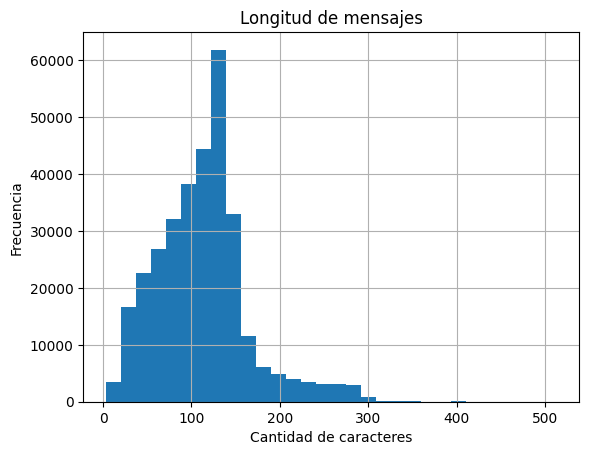

In [ ]:
import matplotlib.pyplot as plt

df_clean["text_length"].hist(bins=30)

plt.title("Longitud de mensajes")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

Palabras de problemas?/ reclamo?

In [ ]:
all_text = " ".join(df_clean["text"].astype(str))

In [ ]:
from collections import Counter

In [ ]:
words = all_text.lower().split()

In [ ]:
Counter(words).most_common(30)

[('to', 182924),
 ('the', 164356),
 ('you', 119481),
 ('i', 101861),
 ('a', 95225),
 ('and', 89423),
 ('for', 84057),
 ('your', 76469),
 ('we', 57984),
 ('is', 57765),
 ('this', 52043),
 ('can', 51778),
 ('my', 51360),
 ('on', 51200),
 ('in', 50092),
 ('with', 47109),
 ('it', 44890),
 ('have', 43536),
 ('us', 42938),
 ('please', 41761),
 ('of', 39560),
 ('that', 31846),
 ('be', 31673),
 ('not', 28676),
 ('are', 28463),
 ('so', 28342),
 ('if', 26799),
 ('dm', 26307),
 ('me', 25812),
 ('our', 24871)]

*no salio lo que esperaba, pense que saldria algo como problemas con el pago, ayuda, problema con el inicio

Palabras de frustracion/enojo/

In [ ]:
keywords = [
    "refund",
    "cancel",
    "error",
    "issue",
    "problem",
    "help",
    "account",
    "payment"
]

In [ ]:
for word in keywords:
    count = df_clean["text"].str.contains(
        word,
        case=False,
        na=False
    ).sum()

    print(word, count)

refund 4466
cancel 4779
error 3737
issue 15661
problem 5379
help 66702
account 13710
payment 1634


grafico

In [ ]:
import pandas as pd

In [ ]:
keyword_counts = {}

In [ ]:
for word in keywords:
    keyword_counts[word] = df_clean["text"].str.contains(
        word,
        case=False,
        na=False
    ).sum()

Aquí ira un pipeline de 3 capas para analizar emoción en texto:

1. IA clasificadora: analiza la columna text y detecta sentimiento.
2. Lógica de negocio: convierte el sentimiento en frustración, escenario y habilidad de entrenamiento.
3. IA generativa: toma casos difíciles y genera roleplays/casos de entrenamiento para agentes.

Paso 1: Dar clasificación a text (imput de cliente) para detectar tono.

In [ ]:
print(df_clean["inbound"].value_counts())

df_clients = df_clean[df_clean["inbound"] == True].copy()

print("Mensajes de clientes:", len(df_clients))
df_clients[["tweet_id", "inbound", "text"]].head()

inbound
True     175703
False    143840
Name: count, dtype: int64
Mensajes de clientes: 175703


,tweet_id,inbound,text
1,2,True,@sprintcare and how do you propose we do that
2,3,True,@sprintcare I have sent several private messag...
4,5,True,@sprintcare I did.
6,8,True,@sprintcare is the worst customer service
8,12,True,@sprintcare You gonna magically change your co...


In [ ]:
df_sample = df_clients.sample(
    n=min(10000, len(df_clients)),
    random_state=42
).copy()

print("Muestra usada:", len(df_sample))

Muestra usada: 10000


In [ ]:
from transformers import pipeline

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
def analizar_sentimiento(texto):
    try:
        resultado = sentiment_analyzer(str(texto)[:512])[0]

        return pd.Series({
            "sentiment_label": resultado["label"].lower(),
            "sentiment_score": resultado["score"]
        })

    except Exception as e:
        return pd.Series({
            "sentiment_label": "error",
            "sentiment_score": 0
        })

df_sample[["sentiment_label", "sentiment_score"]] = df_sample["text"].apply(
    analizar_sentimiento
)

df_sample[["text", "sentiment_label", "sentiment_score"]].head()

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,text,sentiment_label,sentiment_score
244167,@SpotifyCares Samsung S7. Version '8.4.21.508',neutral,0.863986
108841,@115777 @116233 34&gt;60 Euros p.m.. Apparentl...,negative,0.740998
266536,"@nationalrailenq Hey, that's cool, thought you...",positive,0.857428
271163,MCDONALDS HAS CHICKEN TENDERS!!!! @McDonalds h...,positive,0.985161
276713,Aye @116136 y’all going fix the internet? Shit...,negative,0.906179


In [ ]:
df_sample["sentiment_label"].value_counts()

,count
sentiment_label,
negative,5314
neutral,3311
positive,1375


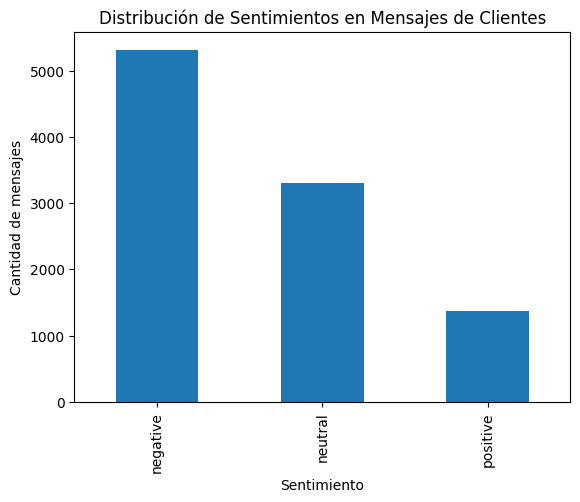

In [ ]:
import matplotlib.pyplot as plt

df_sample["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Distribución de Sentimientos en Mensajes de Clientes")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de mensajes")
plt.show()

Paso 2:

No basta con saber que algo es negativo. Necesitamos saber:

- ¿Por qué está frustrado el cliente?
- ¿Qué escenario de entrenamiento representa?
- ¿Qué habilidad debe practicar el agente?

In [ ]:
detonantes = {
    "Reembolso o dinero": [
        "refund", "money back", "charged", "charge", "payment", "paid", "billing", "bill"
    ],
    "Cancelación": [
        "cancel", "canceled", "cancelled", "cancellation"
    ],
    "Problema técnico": [
        "error", "bug", "not working", "issue", "problem", "broken", "failed", "doesn't work"
    ],
    "Demora o espera": [
        "waiting", "wait", "late", "delay", "delayed", "still waiting", "no response"
    ],
    "Cuenta o acceso": [
        "account", "login", "password", "locked", "access", "sign in", "can't log"
    ],
    "Mala atención": [
        "rude", "terrible service", "bad service", "worst", "unhelpful", "no help"
    ],
    "Entrega o pedido": [
        "order", "delivery", "shipping", "package", "arrived", "missing"
    ]
}

In [ ]:
def detectar_detonante(texto):
    texto = str(texto).lower()

    encontrados = []

    for categoria, palabras in detonantes.items():
        for palabra in palabras:
            if palabra in texto:
                encontrados.append(categoria)
                break

    if encontrados:
        return ", ".join(encontrados)
    else:
        return "No identificado"

df_sample["frustration_trigger"] = df_sample["text"].apply(detectar_detonante)

df_sample[["text", "sentiment_label", "frustration_trigger"]].head()

,text,sentiment_label,frustration_trigger
244167,@SpotifyCares Samsung S7. Version '8.4.21.508',neutral,No identificado
108841,@115777 @116233 34&gt;60 Euros p.m.. Apparentl...,negative,No identificado
266536,"@nationalrailenq Hey, that's cool, thought you...",positive,No identificado
271163,MCDONALDS HAS CHICKEN TENDERS!!!! @McDonalds h...,positive,No identificado
276713,Aye @116136 y’all going fix the internet? Shit...,negative,No identificado


In [ ]:
palabras_fuertes = [
    "angry", "mad", "furious", "frustrated", "upset",
    "ridiculous", "unacceptable", "terrible", "awful",
    "worst", "hate", "disappointed", "annoyed"
]

def calcular_frustracion(row):
    texto = str(row["text"]).lower()
    sentimiento = row["sentiment_label"]
    score = row["sentiment_score"]
    detonante = row["frustration_trigger"]

    tiene_palabra_fuerte = any(palabra in texto for palabra in palabras_fuertes)
    tiene_detonante = detonante != "No identificado"

    if sentimiento == "negative" and score >= 0.85 and tiene_palabra_fuerte:
        return "Alta"

    elif sentimiento == "negative" and score >= 0.75 and tiene_detonante:
        return "Alta"

    elif sentimiento == "negative":
        return "Media"

    elif tiene_detonante:
        return "Media"

    else:
        return "Baja"

df_sample["frustration_level"] = df_sample.apply(calcular_frustracion, axis=1)

df_sample[["text", "sentiment_label", "sentiment_score", "frustration_trigger", "frustration_level"]].head()

,text,sentiment_label,sentiment_score,frustration_trigger,frustration_level
244167,@SpotifyCares Samsung S7. Version '8.4.21.508',neutral,0.863986,No identificado,Baja
108841,@115777 @116233 34&gt;60 Euros p.m.. Apparentl...,negative,0.740998,No identificado,Media
266536,"@nationalrailenq Hey, that's cool, thought you...",positive,0.857428,No identificado,Baja
271163,MCDONALDS HAS CHICKEN TENDERS!!!! @McDonalds h...,positive,0.985161,No identificado,Baja
276713,Aye @116136 y’all going fix the internet? Shit...,negative,0.906179,No identificado,Media


In [ ]:
def asignar_escenario(row):
    detonante = row["frustration_trigger"]
    frustracion = row["frustration_level"]

    if "Reembolso o dinero" in detonante:
        return "Cliente molesto por cobro, pago o solicitud de reembolso"

    elif "Cancelación" in detonante:
        return "Cliente quiere cancelar o reclama por una cancelación"

    elif "Problema técnico" in detonante:
        return "Cliente reporta falla técnica o problema de funcionamiento"

    elif "Demora o espera" in detonante:
        return "Cliente frustrado por demora o falta de respuesta"

    elif "Cuenta o acceso" in detonante:
        return "Cliente con problema de acceso a cuenta"

    elif "Mala atención" in detonante:
        return "Cliente molesto por mala experiencia de atención"

    elif "Entrega o pedido" in detonante:
        return "Cliente reclama por pedido, entrega o envío"

    elif frustracion == "Alta":
        return "Cliente altamente frustrado sin causa explícita"

    elif frustracion == "Media":
        return "Cliente insatisfecho o preocupado"

    else:
        return "Interacción normal o de baja tensión"

df_sample["training_scenario"] = df_sample.apply(asignar_escenario, axis=1)

df_sample[["text", "frustration_level", "frustration_trigger", "training_scenario"]].head()

,text,frustration_level,frustration_trigger,training_scenario
244167,@SpotifyCares Samsung S7. Version '8.4.21.508',Baja,No identificado,Interacción normal o de baja tensión
108841,@115777 @116233 34&gt;60 Euros p.m.. Apparentl...,Media,No identificado,Cliente insatisfecho o preocupado
266536,"@nationalrailenq Hey, that's cool, thought you...",Baja,No identificado,Interacción normal o de baja tensión
271163,MCDONALDS HAS CHICKEN TENDERS!!!! @McDonalds h...,Baja,No identificado,Interacción normal o de baja tensión
276713,Aye @116136 y’all going fix the internet? Shit...,Media,No identificado,Cliente insatisfecho o preocupado


In [ ]:
def recomendar_habilidad(row):
    escenario = row["training_scenario"]
    frustracion = row["frustration_level"]

    if frustracion == "Alta":
        return "Contención emocional, empatía y disculpa clara"

    elif "reembolso" in escenario.lower() or "cobro" in escenario.lower() or "pago" in escenario.lower():
        return "Explicar políticas con claridad y ofrecer solución concreta"

    elif "cancelar" in escenario.lower() or "cancelación" in escenario.lower():
        return "Escucha activa, retención y presentación de alternativas"

    elif "falla técnica" in escenario.lower() or "problema" in escenario.lower():
        return "Diagnóstico, preguntas precisas y seguimiento"

    elif "demora" in escenario.lower() or "falta de respuesta" in escenario.lower():
        return "Reconocer la espera, disculparse y recuperar confianza"

    elif "mala experiencia" in escenario.lower():
        return "Empatía, reparación del vínculo y comunicación calmada"

    elif "pedido" in escenario.lower() or "entrega" in escenario.lower():
        return "Claridad operativa, trazabilidad y solución rápida"

    else:
        return "Comunicación clara, cordialidad y orientación al cliente"

df_sample["recommended_skill"] = df_sample.apply(recomendar_habilidad, axis=1)

df_sample[
    [
        "text",
        "sentiment_label",
        "sentiment_score",
        "frustration_level",
        "frustration_trigger",
        "training_scenario",
        "recommended_skill"
    ]
].head()

,text,sentiment_label,sentiment_score,frustration_level,frustration_trigger,training_scenario,recommended_skill
244167,@SpotifyCares Samsung S7. Version '8.4.21.508',neutral,0.863986,Baja,No identificado,Interacción normal o de baja tensión,"Comunicación clara, cordialidad y orientación ..."
108841,@115777 @116233 34&gt;60 Euros p.m.. Apparentl...,negative,0.740998,Media,No identificado,Cliente insatisfecho o preocupado,"Comunicación clara, cordialidad y orientación ..."
266536,"@nationalrailenq Hey, that's cool, thought you...",positive,0.857428,Baja,No identificado,Interacción normal o de baja tensión,"Comunicación clara, cordialidad y orientación ..."
271163,MCDONALDS HAS CHICKEN TENDERS!!!! @McDonalds h...,positive,0.985161,Baja,No identificado,Interacción normal o de baja tensión,"Comunicación clara, cordialidad y orientación ..."
276713,Aye @116136 y’all going fix the internet? Shit...,negative,0.906179,Media,No identificado,Cliente insatisfecho o preocupado,"Comunicación clara, cordialidad y orientación ..."


KPI's adicionales para presentar

In [ ]:
print("Distribución de sentimientos:")
print(df_sample["sentiment_label"].value_counts())

print("\nDistribución de niveles de frustración:")
print(df_sample["frustration_level"].value_counts())

print("\nDetonantes más frecuentes:")
print(df_sample["frustration_trigger"].value_counts().head(10))

print("\nEscenarios de entrenamiento más frecuentes:")
print(df_sample["training_scenario"].value_counts().head(10))

print("\nHabilidades recomendadas:")
print(df_sample["recommended_skill"].value_counts().head(10))

Distribución de sentimientos:
sentiment_label
negative    5314
neutral     3311
positive    1375
Name: count, dtype: int64

Distribución de niveles de frustración:
frustration_level
Media    4276
Baja     3929
Alta     1795
Name: count, dtype: int64

Detonantes más frecuentes:
frustration_trigger
No identificado                         7016
Problema técnico                         662
Entrega o pedido                         509
Demora o espera                          431
Reembolso o dinero                       325
Cuenta o acceso                          308
Mala atención                             99
Cancelación                               90
Demora o espera, Entrega o pedido         73
Reembolso o dinero, Entrega o pedido      49
Name: count, dtype: int64

Escenarios de entrenamiento más frecuentes:
training_scenario
Interacción normal o de baja tensión                          3929
Cliente insatisfecho o preocupado                             2915
Cliente reporta falla técnica

Gráficos

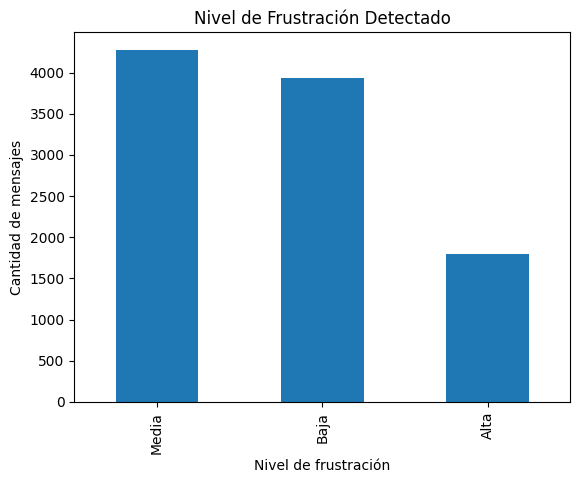

In [ ]:
import matplotlib.pyplot as plt

df_sample["frustration_level"].value_counts().plot(kind="bar")

plt.title("Nivel de Frustración Detectado")
plt.xlabel("Nivel de frustración")
plt.ylabel("Cantidad de mensajes")
plt.show()

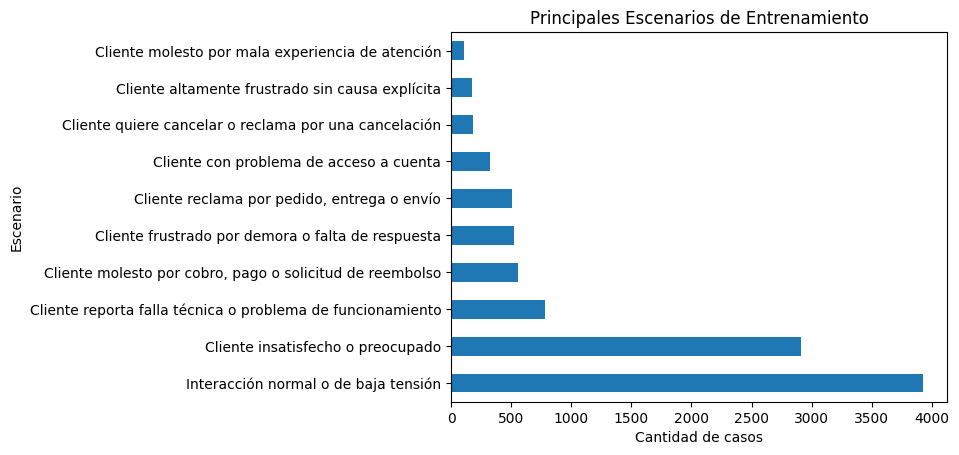

In [ ]:
df_sample["training_scenario"].value_counts().head(10).plot(kind="barh")

plt.title("Principales Escenarios de Entrenamiento")
plt.xlabel("Cantidad de casos")
plt.ylabel("Escenario")
plt.show()

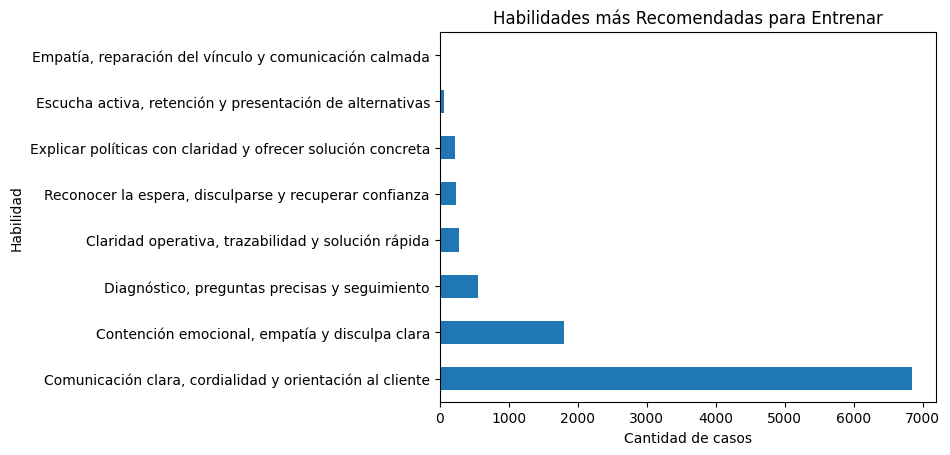

In [ ]:
df_sample["recommended_skill"].value_counts().head(10).plot(kind="barh")

plt.title("Habilidades más Recomendadas para Entrenar")
plt.xlabel("Cantidad de casos")
plt.ylabel("Habilidad")
plt.show()

Paso 3: IA generativa para crear roleplays

La idea es tomar un mensaje difícil y decirle a una IA:

Conviértelo en un caso de entrenamiento para un agente.